In [4]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import time

# =========================== #
#    CREATE GRID WITHOUT FILE #
# =========================== #

# Create a simple grid (20x20)
rows, cols = 20, 20
Z = np.ones((rows, cols))  # 1 = walkable, 0 = obstacle
Z[3:5, 4:6] = 0
Z[16:18, 16:18] = 0
Z[2:4, 15:17] = 0
Z[9:11, 9:11] = 0
Z[16:18, 3:5] = 0

 
print(f"Grid shape: {Z.shape}")

rows, cols = Z.shape
print(f"Grid shape: {Z.shape}")


Grid shape: (20, 20)
Grid shape: (20, 20)


In [5]:
import numpy as np
import heapq

def astar(goal, start):
    rows, cols = Z.shape
    visited = np.full((rows, cols), False)
    dist = np.full((rows, cols), np.inf)
    prev = np.full((rows, cols, 2), -1, dtype=int)

    queue = [(0, goal)]
    dist[goal] = 0

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    while queue:
        current_cost, (x, y) = heapq.heappop(queue)
        
        #  CHECK IF CURRENT CELL IS AN OBSTACLE
        if Z[x, y] == 0:  # Skip if obstacle
            continue
        
        if visited[x, y]:
            continue
        visited[x, y] = True

        if (x, y) == start:
            break

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            
            # CHECK BOUNDS AND OBSTACLES BEFORE EXPLORING
            if 0 <= nx < rows and 0 <= ny < cols and Z[nx, ny] != 0:  # Only if NOT obstacle
                move_cost = np.hypot(dx, dy)
                new_cost = dist[x, y] + move_cost

                # Add heuristic (A*)
                heuristic = np.linalg.norm(np.array([nx, ny]) - np.array(start))
                priority = new_cost + heuristic

                if new_cost < dist[nx, ny]:
                    dist[nx, ny] = new_cost
                    prev[nx, ny] = [x, y]
                    heapq.heappush(queue, (priority, (nx, ny)))

    # Reconstruct path
    path = []
    x, y = start
    while (x, y) != tuple(goal) and prev[x, y, 0] != -1:
        path.append((x, y))
        x, y = prev[x, y]
    if (x, y) != tuple(goal):
        return None, np.inf
    path.append(tuple(goal))
    path.reverse()
    return path, dist[start]

Path found! Cost: 19.80
Time taken: 0.0027 seconds


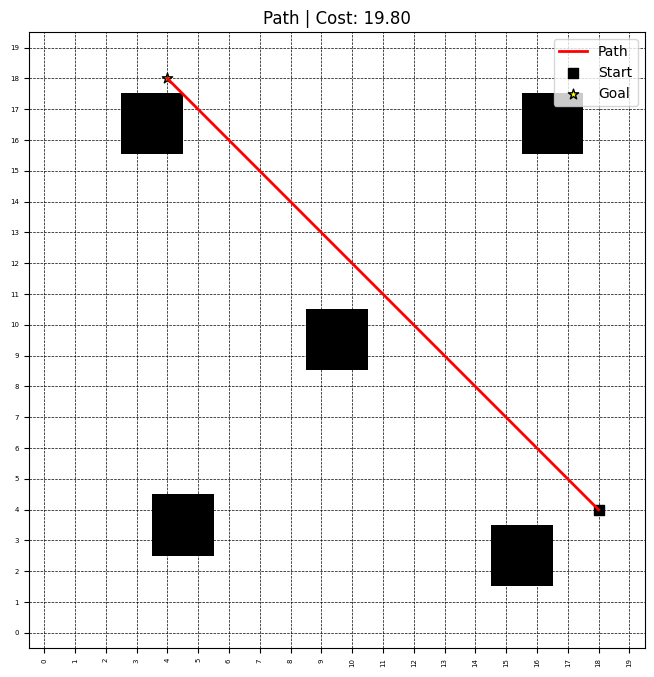

In [6]:
import time

start = (4, 18)  # example start
goal = (18, 4)   # example goal

t0 = time.time()
path, cost = astar(goal, start)
t1 = time.time()

if path is not None:
    print(f"Path found! Cost: {cost:.2f}")
    print(f"Time taken: {t1 - t0:.4f} seconds")
    plt.figure(figsize=(8, 8))
    plt.imshow(Z, cmap='gray', origin='lower')

    plt.grid(True, color='black', linestyle='--', linewidth=0.5)
    plt.xticks(np.arange(0, Z.shape[1], 1), fontsize=5, rotation=90)
    plt.yticks(np.arange(0, Z.shape[0], 1), fontsize=5)
    py, px = zip(*path)
    plt.plot(px, py, color='red', linewidth=2, label='Path')
    #plt.scatter(px, py, color='blue', s=20, marker='o', label='Path Nodes')
    plt.scatter(start[1], start[0], color='black', s=60, marker='s', label='Start')
    plt.scatter(goal[1], goal[0], color='yellow', s=60, edgecolor='black', marker='*', label='Goal')
    plt.title(f"Path | Cost: {cost:.2f}")
    plt.legend()
    plt.show()
else:
    print("No path found.")

In [7]:
import os
import pickle
import numpy as np
from tqdm import tqdm

num_paths = 150000  # Total paths to generate
output_file = "paths_obst27_dataset20.pkl"

rows, cols = Z.shape  

paths_data = []
start_idx = 0
checkpoint_file = "paths_dataset_obst27_checkpoint.pkl"

print(f"Generating {num_paths} paths...")

# Try to resume from checkpoint
if os.path.exists(checkpoint_file):
    try:
        with open(checkpoint_file, "rb") as f:
            paths_data = pickle.load(f)
        start_idx = len(paths_data)
        print(f"Resuming from {start_idx} paths.")
    except Exception as e:
        print("Could not load checkpoint, starting fresh:", e)

def check_path_crosses_obstacle(path, Z):
    """Check if path crosses any obstacle"""
    for x, y in path:
        if Z[x, y] == 0:  # 0 = obstacle
            return True
    return False

def path_to_string_simple(entry):
    """Convert path entry to simple string format (valid & optimal paths only)"""
    path = entry["path"]
    
    # === Format path with f suffix (free cell) ===
    path_str = " ".join([f"{int(x)}-f,{int(y)}-f" for x, y in path])
    
    start = f"{int(path[0][0])}-f,{int(path[0][1])}-f"
    goal = f"{int(path[-1][0])}-f,{int(path[-1][1])}-f"
    
    return f"start: {start} goal: {goal} path: {path_str}"

min_distance = 10  # Minimum Euclidean distance between start and goal

for i in tqdm(range(start_idx, num_paths)):
    max_attempts = 10
    found = False
    
    for attempt in range(max_attempts):
        start = (np.random.randint(0, rows), np.random.randint(0, cols))
        goal = (np.random.randint(0, rows), np.random.randint(0, cols))
        
        # Both start and goal must be on walkable cells and different, and far enough apart
        if (start != goal and Z[start[0], start[1]] > 0 and Z[goal[0], goal[1]] > 0 and
            np.linalg.norm(np.array(start) - np.array(goal)) >= min_distance):
            path, cost = astar(goal, start)
            
            # Check if path is valid and doesn't cross obstacles
            if path is not None and not check_path_crosses_obstacle(path, Z):
                # Get obstacle coordinates
                obstacle_positions = np.where(Z == 0)
                obstacles = list(zip(obstacle_positions[0], obstacle_positions[1]))
                
                paths_data.append({
                    "start": start,
                    "goal": goal,
                    "path": path,
                    "cost": cost,
                    "obstacles": obstacles
                })
                found = True
                break
    
    if not found:
        pass  # Skip if no valid path found after max attempts
    
    # Save checkpoint every 50000 paths
    if (i + 1) % 50000 == 0:
        with open(checkpoint_file, "wb") as f:
            pickle.dump(paths_data, f)
        print(f"Checkpoint saved at {len(paths_data)} paths.")

# Final save
with open(output_file, "wb") as f:
    pickle.dump(paths_data, f)
print(f"Done! Saved {len(paths_data)} paths to {output_file}")

# === Save formatted paths to text file ===
formatted_file = "paths_formatted.txt"
with open(formatted_file, "w") as f:
    for entry in paths_data:
        formatted_line = path_to_string_simple(entry)
        f.write(formatted_line + "\n")

print(f"Formatted paths saved to {formatted_file}")

# === Print statistics ===
print(f"\n=== Path Statistics ===")
print(f"Total valid & optimal paths generated: {len(paths_data)}")
print(f"Average path length: {np.mean([len(p['path']) for p in paths_data]):.2f} steps")
print(f"Average cost: {np.mean([p['cost'] for p in paths_data]):.2f}")

# Print sample paths
print("\n=== Sample Valid Optimal Paths ===")
for i in range(min(3, len(paths_data))):
    print(path_to_string_simple(paths_data[i]))


Generating 150000 paths...


  0%|          | 0/150000 [00:00<?, ?it/s]

 33%|███▎      | 50087/150000 [01:45<42:32, 39.15it/s] 

Checkpoint saved at 49930 paths.


 67%|██████▋   | 100073/150000 [03:35<37:57, 21.92it/s]

Checkpoint saved at 99840 paths.


100%|██████████| 150000/150000 [05:30<00:00, 453.60it/s]

Checkpoint saved at 149756 paths.


Done! Saved 149756 paths to paths_obst27_dataset20.pkl
Formatted paths saved to paths_formatted.txt

=== Path Statistics ===
Total valid & optimal paths generated: 149756
Average path length: 13.83 steps
Average cost: 15.10

=== Sample Valid Optimal Paths ===
start: 17-f,12-f goal: 4-f,18-f path: 17-f,12-f 16-f,13-f 15-f,13-f 14-f,13-f 13-f,14-f 12-f,14-f 11-f,15-f 10-f,15-f 9-f,16-f 8-f,16-f 7-f,17-f 6-f,17-f 5-f,17-f 4-f,18-f
start: 14-f,9-f goal: 1-f,12-f path: 14-f,9-f 13-f,9-f 12-f,9-f 11-f,10-f 10-f,11-f 9-f,11-f 8-f,12-f 7-f,12-f 6-f,12-f 5-f,12-f 4-f,12-f 3-f,12-f 2-f,12-f 1-f,12-f
start: 11-f,3-f goal: 4-f,17-f path: 11-f,3-f 10-f,4-f 10-f,5-f 9-f,6-f 9-f,7-f 8-f,8-f 8-f,9-f 7-f,10-f 7-f,11-f 6-f,12-f 6-f,13-f 5-f,14-f 5-f,15-f 4-f,16-f 4-f,17-f


Path 54447 (VALID OPTIMAL): obst: 5-o,15-o 5-o,16-o 6-o,15-o 6-o,16-o start: 2-f,13-f goal: 10-f,11-f path: 2-f,13-f 3-f,13-f 4-f,13-f 5-f,13-f 6-f,13-f 7-f,12-f 8-f,12-f 9-f,11-f 10-f,11-f | Cost: 8.83



NameError: name 'status' is not defined

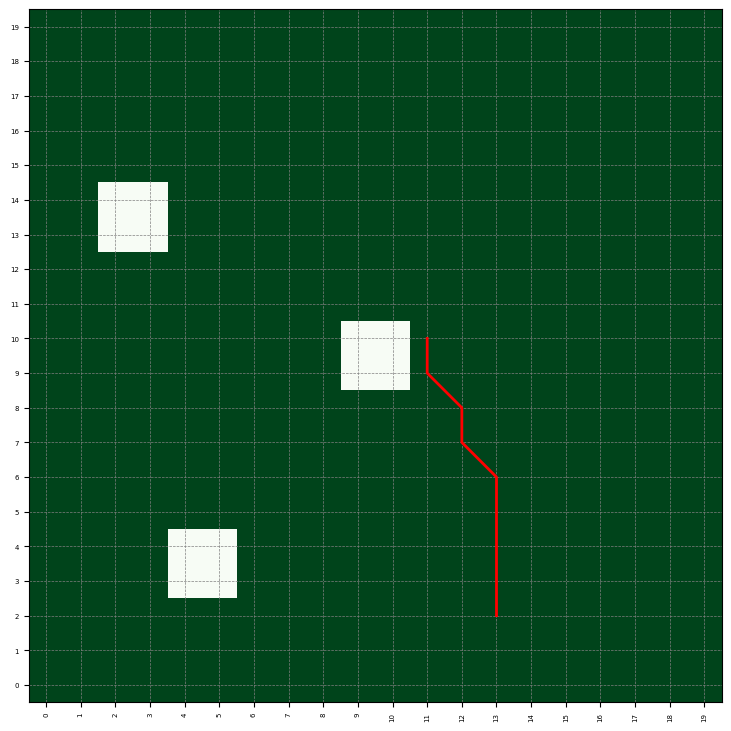

In [9]:
import pickle
import random
import matplotlib.pyplot as plt
import numpy as np

with open('paths_obst3_dataset20.pkl', 'rb') as f:
    paths_data = pickle.load(f)

def path_to_string_formatted(entry):
    """Format path with suffixes - valid & optimal paths only"""
    path = entry["path"]
    obst_list = entry["obstacles"]
    
    # Format path with f suffix (all valid cells)
    path_str = " ".join([f"{int(x)}-f,{int(y)}-f" for x, y in path])
    
    # Format obstacles with o suffix
    obst_str = " ".join([f"{int(x)}-o,{int(y)}-o" for x, y in obst_list]) if obst_list else "none"
    
    # Format start and goal with f suffix
    start = f"{int(path[0][0])}-f,{int(path[0][1])}-f"
    goal = f"{int(path[-1][0])}-f,{int(path[-1][1])}-f"
    
    return f"obst: {obst_str} start: {start} goal: {goal} path: {path_str}"

num_paths = 20
random_indices = random.sample(range(len(paths_data)), num_paths)

for idx in random_indices:
    sample = paths_data[idx]
    start = sample['start']
    goal = sample['goal']
    path = sample['path']
    cost = sample['cost']

    print(f"Path {idx+1} (VALID OPTIMAL): {path_to_string_formatted(sample)} | Cost: {cost:.2f}\n")

    plt.figure(figsize=(9, 9))
    plt.imshow(Z, cmap='Greens', origin='lower')
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
    
    plt.xticks(np.arange(0, Z.shape[1], 1), fontsize=5, rotation=90)
    plt.yticks(np.arange(0, Z.shape[0], 1), fontsize=5)
    
    px, py = zip(*path)
    plt.plot(py, px, color='red', linewidth=2, label='Path')
    
    # Color code start/goal based on status
    start_color = 'green' if status == 'valid' else 'red'
    
    plt.scatter(start[1], start[0], color=start_color, s=100, marker='*', label=f'Start ({status})')
    plt.scatter(goal[1], goal[0], color='yellow', s=100, edgecolor='black', marker='s', label='Goal')
    
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.title(f"Path {idx+1} ({status.upper()}) | Cost: {cost:.2f}")
    plt.legend()
    plt.show()

In [ ]:
import pickle
import numpy as np

with open('500000paths_dataset.pkl', 'rb') as f:
    paths_data = pickle.load(f)

# Average number of steps in the path
avg_steps = np.mean([len(item['path']) for item in paths_data])

# Average Euclidean distance between start and goal
avg_euclid = np.mean([
    np.linalg.norm(np.array(item['start']) - np.array(item['goal']))
    for item in paths_data
])

print(f"Average number of steps in path: {avg_steps:.2f}")
print(f"Average Euclidean distance between start and goal: {avg_euclid:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: '500000paths_dataset.pkl'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

import pickle

# Load the paths dataset
with open('/content/drive/MyDrive/paths_dataset.pkl', 'rb') as f:
    paths_data = pickle.load(f)


# === Load elevation data from CSV ===
df = pd.read_csv('/content/drive/MyDrive/map.csv')

# Convert to 2D grid
pivot_table = df.pivot_table(index='y', columns='x', values='value')
X, Y = np.meshgrid(pivot_table.columns.values, pivot_table.index.values)
Z = pivot_table.values

# === Load 1 random path from paths_data ===
sample = random.choice(paths_data)
start = sample['start']     # (i, j)
goal = sample['goal']       # (i, j)
path = sample['path']       # list of (i, j)
cost = sample['cost']

# Convert path from (i, j) to real-world X, Y, Z using the meshgrid
epsilon = 0.5
path_x = [X[i, j] for i, j in path]
path_y = [Y[i, j] for i, j in path]
path_z = [Z[i, j] for i, j in path]

# Compute aspect ratio ranges
x_range = X.max() - X.min()
y_range = Y.max() - Y.min()
z_range = Z.max() - Z.min()

# === Plot 3D terrain and path ===
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# Terrain
surf = ax.plot_surface(X, Y, Z, cmap='YlGnBu', edgecolor='none', alpha=0.3)
ax.plot_wireframe(X, Y, Z, color='k', linewidth=0.5, alpha=0.4,rstride=1, cstride=1)
ax.view_init(elev=30, azim=15)
# Path
ax.plot(path_x, path_y, path_z, color='red', linewidth=3, label='Path')
ax.scatter(path_x[0], path_y[0], path_z[0], color='cyan', s=50, label='Start')
ax.scatter(path_x[-1], path_y[-1], path_z[-1], color='yellow', s=50, label='Goal')

# Labels & styling
ax.set_box_aspect([x_range, y_range, z_range])
ax.set_title(f'3D Terrain Path | Cost: {cost:.2f}')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Elevation')
ax.legend()
fig.colorbar(surf, ax=ax, shrink=1, aspect=10)
plt.tight_layout()
plt.show()


/home/zvi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


ImportError: cannot import name 'docstring' from 'matplotlib' (/home/zvi/.local/lib/python3.10/site-packages/matplotlib/__init__.py)

In [ ]:
import pickle

# Load the paths dataset
with open('/content/drive/MyDrive/paths_dataset.pkl', 'rb') as f:
    paths_data = pickle.load(f)

print(f" Loaded {len(paths_data)} paths.")

#print one path
def print_path_info(sample, idx=None):
    if idx is not None:
        print(f"\n===== Path {idx+1} =====")
    print(f"Start: {sample['start']}")
    print(f"Goal: {sample['goal']}")
    print(f"Cost: {sample['cost']:.4f}")
    print(f"Path: {sample['path']}")

# ============================

# Example 2: Print a specific path
# ============================
index = 40000 # 0-based index, so 99 = 100th path
if index < len(paths_data):
    print_path_info(paths_data[index], idx=index)
#else:
   # print("❗ Index out of range!")
